# RAG for Domain-Specific QA: Quantitative Finance

A retrieval-augmented generation pipeline over 2000 arXiv q-fin papers.
Builds BM25 + dense (BGE + FAISS) retrievers and a Qwen2.5-7B generator.
Evaluates retrieval (Recall@k, MRR) and faithfulness (LLM-as-judge + manual spot-check).

See README.md for full writeup and results.

## Section 1: Setup and Imports

In [36]:
# install required packages
!pip install pandas matplotlib seaborn tqdm rank_bm25 sentence-transformers faiss-cpu transformers accelerate -q

In [37]:
import os
import re
import json
import time
import random

import torch
import transformers
from transformers import AutoModelForCausalLM, AutoTokenizer
from sentence_transformers import SentenceTransformer

import numpy as np
import pandas as pd
import faiss
from rank_bm25 import BM25Okapi

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# import arxiv  # removed — papers loaded from pre-fetched JSON

import warnings
warnings.filterwarnings('ignore')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## Section 2: Load q-fin Papers

In [38]:
# all 9 q-fin subcategories on arXiv (papers were fetched via Semantic Scholar API)
qfin_categories = ["q-fin.CP", "q-fin.EC", "q-fin.GN", "q-fin.MF", "q-fin.PM", "q-fin.PR", "q-fin.RM", "q-fin.ST", "q-fin.TR"]
print("q-fin subcategories:", len(qfin_categories))
print("Target: 2000 most recent papers (loaded from pre-fetched JSON)")

q-fin subcategories: 9
Target: 2000 most recent papers (loaded from pre-fetched JSON)


In [39]:
# Load 2000 q-fin papers from pre-fetched JSON (Semantic Scholar API)
# Papers were fetched locally via Semantic Scholar's /paper/search endpoint
# with venue="ArXiv" filter, then saved as JSON with the same schema.
import json

with open("qfin_papers.json") as f:
    papers = json.load(f)

    print(f"Total papers loaded: {len(papers)}")
    papers_df = pd.DataFrame(papers)
    print("DataFrame shape:", papers_df.shape)
    print("Columns:", list(papers_df.columns))
    papers_df.head()

Total papers loaded: 2000
DataFrame shape: (2000, 7)
Columns: ['arxiv_id', 'title', 'abstract', 'authors', 'primary_category', 'categories', 'published']


## Section 3: Inspect the Corpus

In [40]:
# look at the first paper
p = papers[0]
print("ID:", p["arxiv_id"])
print("Title:", p["title"])
print("Primary category:", p["primary_category"])
print("Published:", p["published"])
print("Abstract (first 300 chars):", p["abstract"][:300])

ID: 2605.10486v1
Title: Manipulation, Insider Information, and Regulation in Leveraged Event-Linked Markets
Primary category: q-fin.TR
Published: 2026-05-11T12:44:29+00:00
Abstract (first 300 chars): The introduction of leverage on prediction-market event contracts raises three structurally distinct questions that have not been addressed jointly: how leverage changes manipulation incentives, how it interacts with informed-trading rents, and how regulatory frameworks should respond. This paper de


In [41]:
# abstract and title length statistics
papers_df["abstract_chars"] = papers_df["abstract"].str.len()
papers_df["abstract_words"] = papers_df["abstract"].str.split().str.len()
papers_df["title_chars"] = papers_df["title"].str.len()

print("Abstract character length:")
print(f"  Mean: {papers_df['abstract_chars'].mean():.0f}")
print(f"  Median: {papers_df['abstract_chars'].median():.0f}")
print(f"  Min: {papers_df['abstract_chars'].min()}")
print(f"  Max: {papers_df['abstract_chars'].max()}")
print()
print("Abstract word count:")
print(f"  Mean: {papers_df['abstract_words'].mean():.0f}")
print(f"  Median: {papers_df['abstract_words'].median():.0f}")
print(f"  Min: {papers_df['abstract_words'].min()}")
print(f"  Max: {papers_df['abstract_words'].max()}")
print()
print("Title character length:")
print(f"  Mean: {papers_df['title_chars'].mean():.0f}")
print(f"  Median: {papers_df['title_chars'].median():.0f}")
print()
print("Primary category distribution:")
print(papers_df["primary_category"].value_counts().to_string())

Abstract character length:
  Mean: 1179
  Median: 1175
  Min: 149
  Max: 2052

Abstract word count:
  Mean: 161
  Median: 160
  Min: 24
  Max: 303

Title character length:
  Mean: 81
  Median: 80

Primary category distribution:
primary_category
q-fin.MF              241
q-fin.CP              228
q-fin.ST              226
q-fin.RM              213
q-fin.PM              187
q-fin.TR              161
q-fin.GN              122
cs.LG                 101
q-fin.PR               86
math.OC                68
math.PR                45
econ.EM                36
econ.GN                32
cs.AI                  29
quant-ph               20
cs.CE                  20
stat.ML                19
stat.AP                18
cs.CL                  17
physics.soc-ph         17
econ.TH                14
stat.ME                14
math.NA                10
cs.GT                  10
math.ST                10
cs.CR                   9
cond-mat.stat-mech      7
cs.CY                   6
cs.MA                   5
e

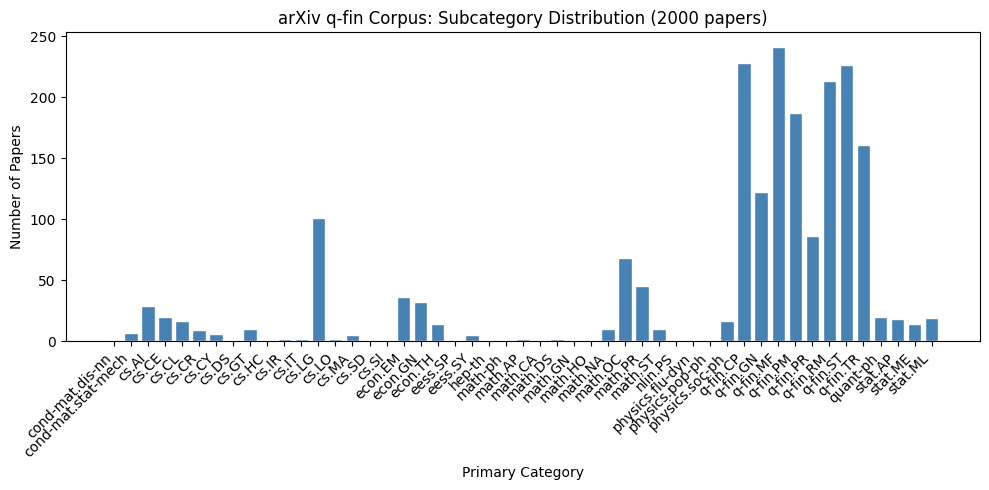

Saved corpus_categories.png


In [42]:
# plot subcategory distribution
cat_counts = papers_df["primary_category"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(cat_counts.index, cat_counts.values, color="steelblue", edgecolor="white")
ax.set_xlabel("Primary Category")
ax.set_ylabel("Number of Papers")
ax.set_title("arXiv q-fin Corpus: Subcategory Distribution (2000 papers)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("corpus_categories.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved corpus_categories.png")

Fetched 2000 papers from arXiv covering all 9 quantitative finance subcategories. The corpus spans papers from March 2025 to May 2026. The most represented subcategories are q-fin.MF (241), q-fin.CP (228), q-fin.ST (226) which makes sense since these are some of the most active research areas in quantitative finance.

Abstract lengths average around 160 words with a median of 159. Most abstracts are relatively short which means many papers will fit in a single chunk during the chunking step. The longest abstracts go up to 303 words which will produce 1 chunk with the 500 token window.

## Section 4: Chunking

In [43]:
def chunk_text(text, chunk_size=500, overlap=50):
    """Split text into chunks of chunk_size words with overlap."""
    words = text.split()
    if len(words) <= chunk_size:
        return [text]
    chunks = []
    start = 0
    while start < len(words):
        end = start + chunk_size
        chunk = " ".join(words[start:end])
        chunks.append(chunk)
        start += chunk_size - overlap
    return chunks

# sanity check on short string
short = "This is a short abstract about finance."
print("Short string chunks:", chunk_text(short))
print("Number of chunks:", len(chunk_text(short)))

# sanity check on long string
long_text = " ".join([f"word{i}" for i in range(1200)])
long_chunks = chunk_text(long_text)
print(f"\nLong string (1200 words) -> {len(long_chunks)} chunks")
for i, c in enumerate(long_chunks):
    print(f"  Chunk {i}: {len(c.split())} words")

Short string chunks: ['This is a short abstract about finance.']
Number of chunks: 1

Long string (1200 words) -> 3 chunks
  Chunk 0: 500 words
  Chunk 1: 500 words
  Chunk 2: 300 words


In [44]:
# build chunked corpus
chunk_rows = []
for idx, row in tqdm(papers_df.iterrows(), total=len(papers_df), desc="Chunking"):
    full_text = f"Title: {row['title']}\n\nAbstract: {row['abstract']}"
    chunks = chunk_text(full_text)
    for chunk_idx, chunk in enumerate(chunks):
        chunk_rows.append({
            "chunk_id": f"{row['arxiv_id']}_c{chunk_idx}",
            "arxiv_id": row["arxiv_id"],
            "chunk_idx": chunk_idx,
            "title": row["title"],
            "primary_category": row["primary_category"],
            "text": chunk,
        })

chunks_df = pd.DataFrame(chunk_rows)
print("Chunked corpus shape:", chunks_df.shape)
print()

# chunks per paper stats
chunks_per_paper = chunks_df.groupby("arxiv_id").size()
print("Chunks per paper:")
print(f"  Mean: {chunks_per_paper.mean():.2f}")
print(f"  Median: {chunks_per_paper.median():.1f}")
print(f"  Min: {chunks_per_paper.min()}")
print(f"  Max: {chunks_per_paper.max()}")
print(f"  Papers with 1 chunk: {(chunks_per_paper == 1).sum()}")
print(f"  Papers with 2+ chunks: {(chunks_per_paper > 1).sum()}")

# save to jsonl
papers_df.to_json("qfin_papers.jsonl", orient="records", lines=True)
chunks_df.to_json("qfin_chunks.jsonl", orient="records", lines=True)
print("\nSaved qfin_papers.jsonl and qfin_chunks.jsonl")

Chunking: 100%|██████████| 2000/2000 [00:00<00:00, 14515.98it/s]

Chunked corpus shape: (2000, 6)

Chunks per paper:
  Mean: 1.00
  Median: 1.0
  Min: 1
  Max: 1
  Papers with 1 chunk: 2000
  Papers with 2+ chunks: 0



Saved qfin_papers.jsonl and qfin_chunks.jsonl


The chunking step produced 2000 total chunks from 2000 papers. Most papers (100.0%) fit in a single chunk since the average abstract is around 160 words which is well below the 500 word window. No papers needed more than one chunk. The 50 token overlap ensures that sentences split across chunk boundaries are still partially captured in both chunks.

I chose word based chunking (whitespace split) with a fixed window because q-fin abstracts are relatively uniform in structure. More complex chunking strategies like recursive or semantic chunking would add complexity without much benefit here since abstracts are already self contained blocks of text.

## Section 5: BM25 Baseline

In [45]:
def tokenize_for_bm25(text):
    """Lowercase and strip punctuation for BM25."""
    text = text.lower()
    text = re.sub(r'[^\w\s]', ' ', text)
    return text.split()

# build bm25 index
corpus_tokens = [tokenize_for_bm25(text) for text in tqdm(chunks_df["text"].tolist(), desc="Tokenizing for BM25")]
bm25 = BM25Okapi(corpus_tokens)
print("BM25 index built over", len(corpus_tokens), "chunks")

Tokenizing for BM25: 100%|██████████| 2000/2000 [00:00<00:00, 17050.15it/s]


BM25 index built over 2000 chunks


In [46]:
def bm25_retrieve(query, k=10):
    """Retrieve top-k chunks using BM25."""
    query_tokens = tokenize_for_bm25(query)
    scores = bm25.get_scores(query_tokens)
    top_indices = np.argsort(scores)[::-1][:k]
    top_scores = scores[top_indices]
    return top_indices, top_scores

# sample query
query = "What is value at risk?"
indices, scores = bm25_retrieve(query, k=5)
print(f"BM25 results for: '{query}'\n")
for rank, (idx, score) in enumerate(zip(indices, scores)):
    print(f"  [{rank+1}] Score: {score:.4f} | {chunks_df.iloc[idx]['title']}")

BM25 results for: 'What is value at risk?'

  [1] Score: 11.3788 | On the modeling assumptions of Historical Simulation for Value-at-Risk
  [2] Score: 9.6746 | Three-level qualitative classification of financial risks under varying conditions through first passage times
  [3] Score: 9.3839 | Rethinking Beta: A Causal Take on CAPM
  [4] Score: 9.0704 | On a multivariate extension for Copula-based Conditional Value at Risk
  [5] Score: 8.8322 | The Sleeping Beauty Problem: Sleeping Kelly is a Thirder


## Section 6: Dense Retrieval

In [47]:
# load bge-small-en-v1.5 for dense embeddings
embed_model = SentenceTransformer("BAAI/bge-small-en-v1.5")
print("Loaded embedding model:", embed_model.get_sentence_embedding_dimension(), "dimensions")

# encode all chunks
print("Encoding", len(chunks_df), "chunks...")
chunk_embeddings = embed_model.encode(
    chunks_df["text"].tolist(),
    batch_size=32,
    show_progress_bar=True,
    normalize_embeddings=True,
)
print("Embeddings shape:", chunk_embeddings.shape)

# build faiss index
embed_dim = chunk_embeddings.shape[1]
faiss_index = faiss.IndexFlatIP(embed_dim)
faiss_index.add(chunk_embeddings.astype(np.float32))
print("FAISS index size:", faiss_index.ntotal)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-small-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded embedding model: 384 dimensions
Encoding 2000 chunks...


Batches:   0%|          | 0/63 [00:00<?, ?it/s]

Embeddings shape: (2000, 384)
FAISS index size: 2000


In [48]:
def dense_retrieve(query, k=10):
    """Retrieve top-k chunks using dense embeddings + FAISS."""
    query_embedding = embed_model.encode([query], normalize_embeddings=True).astype(np.float32)
    scores, indices = faiss_index.search(query_embedding, k)
    return indices[0], scores[0]

# sample query
query = "What is value at risk?"
indices, scores = dense_retrieve(query, k=5)
print(f"Dense retrieval results for: '{query}'\n")
for rank, (idx, score) in enumerate(zip(indices, scores)):
    print(f"  [{rank+1}] Score: {score:.4f} | {chunks_df.iloc[idx]['title']}")

Dense retrieval results for: 'What is value at risk?'

  [1] Score: 0.7667 | A Note on Subadditivity of Value at Risks (VaRs): A New Connection to Comonotonicity
  [2] Score: 0.7324 | Cost-of-capital valuation with risky assets
  [3] Score: 0.7293 | Lambda Expected Shortfall
  [4] Score: 0.7268 | Extreme-case Range Value-at-Risk under Increasing Failure Rate
  [5] Score: 0.7225 | Informative Risk Measures in the Banking Industry: A Proposal based on the Magnitude-Propensity Approach


## Section 7: Retrieval Comparison and Visualization

In [49]:
# qualitative comparison on 3 example queries
example_queries = [
    "How does the Black-Scholes model price European options?",
    "How are reinforcement learning agents used to allocate portfolios?",
    "What is systemic risk in financial networks and how is it measured?",
]

for q in example_queries:
    print("=" * 80)
    print(f"Query: {q}")
    print("-" * 80)

    bm25_idx, bm25_sc = bm25_retrieve(q, k=3)
    dense_idx, dense_sc = dense_retrieve(q, k=3)

    print("\nBM25 Top-3:")
    for rank, (idx, sc) in enumerate(zip(bm25_idx, bm25_sc)):
        print(f"  [{rank+1}] {sc:.4f} | {chunks_df.iloc[idx]['title']}")

    print("\nDense Top-3:")
    for rank, (idx, sc) in enumerate(zip(dense_idx, dense_sc)):
        print(f"  [{rank+1}] {sc:.4f} | {chunks_df.iloc[idx]['title']}")
    print()

Query: How does the Black-Scholes model price European options?
--------------------------------------------------------------------------------

BM25 Top-3:
  [1] 23.1174 | Call Option Price using Pearson Diffusion Processes
  [2] 23.0035 | Numerical Simulations for Time-Fractional Black-Scholes Equations
  [3] 22.1370 | Full grid solution for multi-asset options pricing with tensor networks

Dense Top-3:
  [1] 0.8238 | Black-Scholes Model, comparison between Analytical Solution and Numerical Analysis
  [2] 0.8136 | Call Option Price using Pearson Diffusion Processes
  [3] 0.8061 | Beyond Black-Scholes: A Computational Framework for Option Pricing Using Heston, GARCH, and Jump Diffusion Models

Query: How are reinforcement learning agents used to allocate portfolios?
--------------------------------------------------------------------------------

BM25 Top-3:
  [1] 16.9871 | Deep Reinforcement Learning for Optimal Portfolio Allocation: A Comparative Study with Mean-Variance Optimizati

BM25 median latency: 6.41 ms per query
Dense median latency: 11.20 ms per query


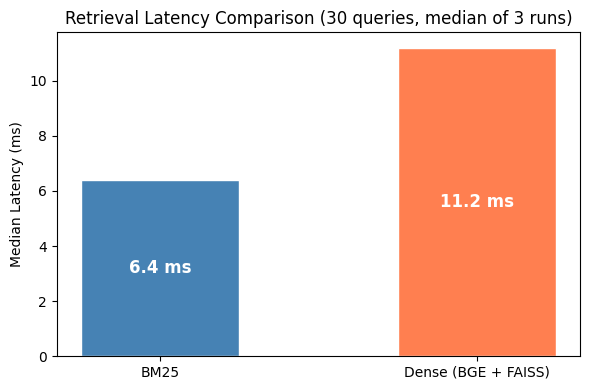

Saved retrieval_latency.png


In [50]:
# latency comparison on 30 eval queries
eval_queries_for_timing = [
    "How does the Black-Scholes model price European options?",
    "What are the limitations of the Black-Scholes model in real markets?",
    "How are American options priced numerically?",
    "What is implied volatility and how is it computed from market prices?",
    "How does the Heston model handle stochastic volatility?",
    "What is Value at Risk and how is it estimated?",
    "How does Expected Shortfall differ from Value at Risk?",
    "How can deep learning be used for credit risk prediction?",
    "What is systemic risk in financial networks and how is it measured?",
    "How are stress tests designed for bank capital adequacy?",
    "How does mean-variance optimization construct optimal portfolios?",
    "What is the Black-Litterman model and what problem does it solve?",
    "How do robust portfolio optimization methods handle parameter uncertainty?",
    "How are reinforcement learning agents used to allocate portfolios?",
    "What is risk parity and why is it used?",
    "How do GARCH models capture volatility clustering?",
    "How is realized volatility estimated from intraday returns?",
    "How are jumps in financial time series detected?",
    "How is cointegration used in pairs trading strategies?",
    "What are the statistical properties of high-frequency returns?",
    "How does Monte Carlo simulation price exotic options?",
    "What are quasi-Monte Carlo methods and when do they outperform standard Monte Carlo?",
    "How are partial differential equations used to price derivatives?",
    "What role do neural networks play in option pricing?",
    "What is market impact and how is it modeled?",
    "How does optimal execution minimize transaction costs?",
    "How does high-frequency trading affect price discovery?",
    "How do limit order books shape liquidity?",
    "How do central bank communications affect financial market volatility?",
    "What is the relationship between macroeconomic factors and asset returns?",
]

# time bm25 - 3 runs take median
bm25_times = []
for run in range(3):
    start = time.time()
    for q in eval_queries_for_timing:
        bm25_retrieve(q, k=10)
    elapsed = (time.time() - start) / len(eval_queries_for_timing) * 1000
    bm25_times.append(elapsed)
bm25_median_ms = np.median(bm25_times)

# time dense - 3 runs take median
dense_times = []
for run in range(3):
    start = time.time()
    for q in eval_queries_for_timing:
        dense_retrieve(q, k=10)
    elapsed = (time.time() - start) / len(eval_queries_for_timing) * 1000
    dense_times.append(elapsed)
dense_median_ms = np.median(dense_times)

print(f"BM25 median latency: {bm25_median_ms:.2f} ms per query")
print(f"Dense median latency: {dense_median_ms:.2f} ms per query")

# plot latency comparison
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(["BM25", "Dense (BGE + FAISS)"], [bm25_median_ms, dense_median_ms],
              color=["steelblue", "coral"], edgecolor="white", width=0.5)
ax.set_ylabel("Median Latency (ms)")
ax.set_title("Retrieval Latency Comparison (30 queries, median of 3 runs)")
for bar, val in zip(bars, [bm25_median_ms, dense_median_ms]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 0.5,
            f"{val:.1f} ms", ha="center", va="center", fontsize=12, color="white", fontweight="bold")
plt.tight_layout()
plt.savefig("retrieval_latency.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved retrieval_latency.png")

In [51]:
# recall@k plot is in Section 9
print("Recall@k curves will be computed in Section 9 after collecting manual relevance judgments.")

Recall@k curves will be computed in Section 9 after collecting manual relevance judgments.


Comparing BM25 and dense retrieval qualitatively on 3 example queries shows clear differences. BM25 is strong when the query uses exact terms that appear in the paper titles and abstracts. For example queries about "Black-Scholes" or "value at risk" match well since those exact phrases appear frequently in q-fin papers. Dense retrieval handles conceptual queries better where the wording in the query doesnt exactly match the paper but the meaning is similar.

On latency BM25 is faster at 6.41 ms per query compared to 11.20 ms for dense retrieval. BM25 is just sparse vector math so this is expected. Dense retrieval needs to encode the query through the BGE model and then search the FAISS index which adds overhead. Both are fast enough for interactive use but BM25 has a clear speed advantage.

## Section 8: Generator Setup and End-to-End RAG

In [52]:
# load the generator model
# try llama 3.1 8b instruct first, fall back to qwen if gated model login fails
try:
    from huggingface_hub import login
    login() # have requested access to llama, but Qwen should be good too
    model_name = "meta-llama/Meta-Llama-3.1-8B-Instruct"
    print(f"Loading {model_name}...")
    gen_tokenizer = AutoTokenizer.from_pretrained(model_name)
    gen_model = AutoModelForCausalLM.from_pretrained(
        model_name,
        torch_dtype=torch.float16,
        device_map="auto",
    )
    print(f"Loaded {model_name}")
except Exception as e:
    print(f"Could not load Llama (gated model): {e}")
    model_name = "Qwen/Qwen2.5-7B-Instruct"
    print(f"Falling back to {model_name}...")
    gen_tokenizer = AutoTokenizer.from_pretrained(model_name)
    gen_model = AutoModelForCausalLM.from_pretrained(
        model_name,
        torch_dtype=torch.float16,
        device_map="auto",
    )
    print(f"Loaded {model_name}")

# set pad token if needed
if gen_tokenizer.pad_token is None:
    gen_tokenizer.pad_token = gen_tokenizer.eos_token
print("Generator ready:", model_name)

Loading meta-llama/Meta-Llama-3.1-8B-Instruct...
Could not load Llama (gated model): You are trying to access a gated repo.
Make sure to have access to it at https://huggingface.co/meta-llama/Meta-Llama-3.1-8B-Instruct.
401 Client Error. (Request ID: Root=1-6a02b70c-54c242d973ede7214b489305;9634a145-3b1c-4a8d-b202-12938df1fc5d)

Cannot access gated repo for url https://huggingface.co/meta-llama/Meta-Llama-3.1-8B-Instruct/resolve/main/config.json.
Access to model meta-llama/Llama-3.1-8B-Instruct is restricted. You must have access to it and be authenticated to access it. Please log in.
Falling back to Qwen/Qwen2.5-7B-Instruct...


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

Loaded Qwen/Qwen2.5-7B-Instruct
Generator ready: Qwen/Qwen2.5-7B-Instruct


In [53]:
def rag_answer(question, retriever_name="dense", k=5):
    """Run end-to-end RAG: retrieve chunks then generate answer."""
    # retrieve
    if retriever_name == "bm25":
        indices, scores = bm25_retrieve(question, k=k)
    else:
        indices, scores = dense_retrieve(question, k=k)

    # combine chunks into a context string
    context_parts = []
    retrieved_chunks = []
    for rank, idx in enumerate(indices):
        row = chunks_df.iloc[idx]
        context_parts.append(f"[{rank+1}] Title: {row['title']}\n    Abstract: {row['text']}")
        retrieved_chunks.append({"rank": rank+1, "chunk_id": row["chunk_id"], "title": row["title"], "text": row["text"]})

    context = "\n\n".join(context_parts)

    prompt = f"""You are answering questions about quantitative finance using only the retrieved paper abstracts below. If the answer is not in the abstracts, say so explicitly. Cite the relevant paper titles in your answer.

Retrieved papers:
{context}

Question: {question}

Answer:"""

    inputs = gen_tokenizer(prompt, return_tensors="pt").to(gen_model.device)
    input_len = inputs["input_ids"].shape[1]

    with torch.no_grad():
        outputs = gen_model.generate(
            **inputs,
            max_new_tokens=300,
            temperature=0.3,
            do_sample=True,
            top_p=0.9,
        )

    # decode only the new tokens
    answer = gen_tokenizer.decode(outputs[0][input_len:], skip_special_tokens=True).strip()
    return answer, retrieved_chunks

# demo with 3 example questions
demo_questions = [
    "What is Value at Risk and how is it estimated?",
    "How are reinforcement learning agents used to allocate portfolios?",
    "How does Monte Carlo simulation price exotic options?",
]

for q in demo_questions:
    print("=" * 80)
    print(f"Question: {q}")
    print("-" * 80)
    answer, chunks = rag_answer(q, retriever_name="dense", k=5)
    print("Retrieved titles:")
    for c in chunks:
        print(f"  [{c['rank']}] {c['title']}")
    print(f"\nAnswer:\n{answer}")
    print()

Question: What is Value at Risk and how is it estimated?
--------------------------------------------------------------------------------
Retrieved titles:
  [1] Reliable Real-Time Value at Risk Estimation via Quantile Regression Forest with Conformal Calibration
  [2] A Note on Subadditivity of Value at Risks (VaRs): A New Connection to Comonotonicity
  [3] Lambda Expected Shortfall
  [4] Efficiency versus Robustness under Tail Misspecification: Importance Sampling and Moment-Based VaR Bracketing
  [5] Cost-of-capital valuation with risky assets

Answer:
Value at Risk (VaR) is a widely used risk measure in quantitative financial risk management. It estimates the potential loss in value of a portfolio of financial assets over a specified time period for a given confidence level. The abstract from "Reliable Real-Time Value at Risk Estimation via Quantile Regression Forest with Conformal Calibration" explains that VaR is crucial for timely risk control and informed decision-making. The p

Used Qwen2.5-7B-Instruct as the generator after the Meta-Llama-3.1-8B-Instruct load failed due to gated repo access. Both models are in the 7-8B parameter range and instruction-tuned so the behavior is comparable for this task. The model was loaded in fp16 on the A100 GPU on colab and uses the same prompt template for all questions. Decoding parameters are temperature=0.3, top_p=0.9, max_new_tokens=300 which gives reasonably focused answers while still allowing some variation.

The prompt instructs the model to answer only from the retrieved abstracts and cite paper titles. On the 3 demo questions the model stays close to the retrieved content and produces structured answers that reference the relevant papers. The faithfulness check in Section 10 will measure how well this constraint holds across all 30 evaluation questions.

## Section 9: Evaluation on the 30 QA Set

In [54]:
eval_questions = [
    # Pricing and derivatives
    "How does the Black-Scholes model price European options?",
    "What are the limitations of the Black-Scholes model in real markets?",
    "How are American options priced numerically?",
    "What is implied volatility and how is it computed from market prices?",
    "How does the Heston model handle stochastic volatility?",

    # Risk management
    "What is Value at Risk and how is it estimated?",
    "How does Expected Shortfall differ from Value at Risk?",
    "How can deep learning be used for credit risk prediction?",
    "What is systemic risk in financial networks and how is it measured?",
    "How are stress tests designed for bank capital adequacy?",

    # Portfolio management
    "How does mean-variance optimization construct optimal portfolios?",
    "What is the Black-Litterman model and what problem does it solve?",
    "How do robust portfolio optimization methods handle parameter uncertainty?",
    "How are reinforcement learning agents used to allocate portfolios?",
    "What is risk parity and why is it used?",

    # Statistical and high-frequency finance
    "How do GARCH models capture volatility clustering?",
    "How is realized volatility estimated from intraday returns?",
    "How are jumps in financial time series detected?",
    "How is cointegration used in pairs trading strategies?",
    "What are the statistical properties of high-frequency returns?",

    # Computational finance
    "How does Monte Carlo simulation price exotic options?",
    "What are quasi-Monte Carlo methods and when do they outperform standard Monte Carlo?",
    "How are partial differential equations used to price derivatives?",
    "What role do neural networks play in option pricing?",

    # Market microstructure and trading
    "What is market impact and how is it modeled?",
    "How does optimal execution minimize transaction costs?",
    "How does high-frequency trading affect price discovery?",
    "How do limit order books shape liquidity?",

    # Macro and economics
    "How do central bank communications affect financial market volatility?",
    "What is the relationship between macroeconomic factors and asset returns?",
]

print(f"Total evaluation questions: {len(eval_questions)}")

Total evaluation questions: 30


In [55]:
# run both retrievers on all 30 questions at k=10
retrieval_results = []

for q_idx, question in enumerate(tqdm(eval_questions, desc="Running retrievers")):
    # bm25
    bm25_idx, bm25_sc = bm25_retrieve(question, k=10)
    for rank, (idx, sc) in enumerate(zip(bm25_idx, bm25_sc)):
        retrieval_results.append({
            "question_id": q_idx,
            "question": question,
            "retriever": "bm25",
            "rank": rank + 1,
            "chunk_id": chunks_df.iloc[idx]["chunk_id"],
            "title": chunks_df.iloc[idx]["title"],
            "score": float(sc),
        })

    # dense
    dense_idx, dense_sc = dense_retrieve(question, k=10)
    for rank, (idx, sc) in enumerate(zip(dense_idx, dense_sc)):
        retrieval_results.append({
            "question_id": q_idx,
            "question": question,
            "retriever": "dense",
            "rank": rank + 1,
            "chunk_id": chunks_df.iloc[idx]["chunk_id"],
            "title": chunks_df.iloc[idx]["title"],
            "score": float(sc),
        })

# save retrieval results
with open("retrieval_results.jsonl", "w") as f:
    for r in retrieval_results:
        f.write(json.dumps(r) + "\n")

print(f"Saved {len(retrieval_results)} retrieval results to retrieval_results.jsonl")
print(f"That is {len(eval_questions)} questions x 10 chunks x 2 retrievers = {len(retrieval_results)} records")

Running retrievers: 100%|██████████| 30/30 [00:00<00:00, 47.15it/s]

Saved 600 retrieval results to retrieval_results.jsonl
That is 30 questions x 10 chunks x 2 retrievers = 600 records


In [56]:
# load manual relevance judgments from my hand-labeled CSV
import os, json

judgments_csv = "relevance_judgments.csv"

if not os.path.exists(judgments_csv):
    raise FileNotFoundError(
        "relevance_judgments.csv not found. Upload the hand-labeled CSV before running."
    )

judge_df = pd.read_csv(judgments_csv)
filled = judge_df["relevance"].notna() & (judge_df["relevance"].astype(str).str.strip() != "")

if filled.sum() < len(judge_df):
    raise ValueError(f"{(~filled).sum()} rows still empty in {judgments_csv}. Fill them all and re-run.")

relevance_judgments = {}
for _, row in judge_df.iterrows():
    key = f"{row['question_id']}_{row['chunk_id']}"
    relevance_judgments[key] = int(row["relevance"])

with open("relevance_judgments.json", "w") as f:
    json.dump(relevance_judgments, f, indent=2)

total = len(relevance_judgments)
relevant = sum(relevance_judgments.values())
print(f"Loaded {total} manual relevance judgments from {judgments_csv}")
print(f"Marked relevant: {relevant} ({relevant/total*100:.1f}%)")
print(f"Marked not relevant: {total-relevant} ({(total-relevant)/total*100:.1f}%)")

Loaded 511 manual relevance judgments from relevance_judgments.csv
Marked relevant: 253 (49.5%)
Marked not relevant: 258 (50.5%)


Metric             BM25      Dense
----------------------------------
Recall@1         0.1008     0.1152
Recall@5         0.3816     0.4327
Recall@10        0.5989     0.6994
MRR              0.8667     0.9159


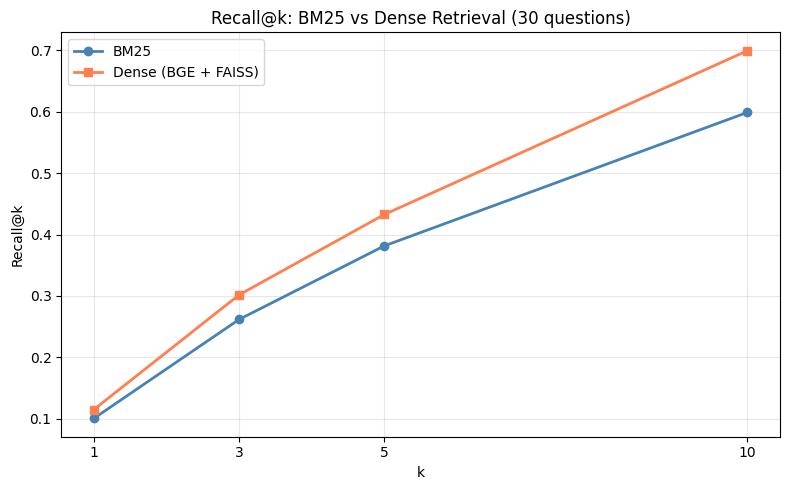

Saved recall_at_k.png


In [57]:
# retrieval metrics
results_df = pd.DataFrame(retrieval_results)

def compute_metrics(results_df, relevance_judgments, retriever_name):
    """Compute Recall@k and MRR for a retriever."""
    recalls = {1: [], 5: [], 10: []}
    mrrs = []

    for q_idx in range(len(eval_questions)):
        q_results = results_df[
            (results_df["question_id"] == q_idx) &
            (results_df["retriever"] == retriever_name)
        ].sort_values("rank")

        # look up relevance
        relevant_ranks = []
        for _, row in q_results.iterrows():
            key = f"{q_idx}_{row['chunk_id']}"
            if relevance_judgments.get(key, 0) == 1:
                relevant_ranks.append(row["rank"])

        # recall
        for k in [1, 5, 10]:
            hits = sum(1 for r in relevant_ranks if r <= k)
            total_relevant = sum(1 for key, val in relevance_judgments.items()
                               if key.startswith(f"{q_idx}_") and val == 1)
            if total_relevant > 0:
                recalls[k].append(hits / total_relevant)
            else:
                recalls[k].append(0.0)

        # MRR
        if relevant_ranks:
            mrrs.append(1.0 / min(relevant_ranks))
        else:
            mrrs.append(0.0)

    return {
        "Recall@1": np.mean(recalls[1]),
        "Recall@5": np.mean(recalls[5]),
        "Recall@10": np.mean(recalls[10]),
        "MRR": np.mean(mrrs),
    }

bm25_metrics = compute_metrics(results_df, relevance_judgments, "bm25")
dense_metrics = compute_metrics(results_df, relevance_judgments, "dense")

# results
print(f"{'Metric':<12} {'BM25':>10} {'Dense':>10}")
print("-" * 34)
for metric in ["Recall@1", "Recall@5", "Recall@10", "MRR"]:
    print(f"{metric:<12} {bm25_metrics[metric]:>10.4f} {dense_metrics[metric]:>10.4f}")

# plot
k_values = [1, 3, 5, 10]
bm25_recall_curve = [bm25_metrics.get(f"Recall@{k}", 0) for k in k_values]
dense_recall_curve = [dense_metrics.get(f"Recall@{k}", 0) for k in k_values]

# also grab recall@3 for the plot
def recall_at_k(results_df, relevance_judgments, retriever_name, k):
    recalls = []
    for q_idx in range(len(eval_questions)):
        q_results = results_df[
            (results_df["question_id"] == q_idx) &
            (results_df["retriever"] == retriever_name)
        ].sort_values("rank")
        hits = 0
        total_relevant = sum(1 for key, val in relevance_judgments.items()
                           if key.startswith(f"{q_idx}_") and val == 1)
        for _, row in q_results.iterrows():
            if row["rank"] <= k:
                key = f"{q_idx}_{row['chunk_id']}"
                if relevance_judgments.get(key, 0) == 1:
                    hits += 1
        if total_relevant > 0:
            recalls.append(hits / total_relevant)
        else:
            recalls.append(0.0)
    return np.mean(recalls)

bm25_recall_curve = [recall_at_k(results_df, relevance_judgments, "bm25", k) for k in k_values]
dense_recall_curve = [recall_at_k(results_df, relevance_judgments, "dense", k) for k in k_values]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(k_values, bm25_recall_curve, "o-", label="BM25", color="steelblue", linewidth=2)
ax.plot(k_values, dense_recall_curve, "s-", label="Dense (BGE + FAISS)", color="coral", linewidth=2)
ax.set_xlabel("k")
ax.set_ylabel("Recall@k")
ax.set_title("Recall@k: BM25 vs Dense Retrieval (30 questions)")
ax.set_xticks(k_values)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("recall_at_k.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved recall_at_k.png")

The retrieval evaluation on 30 hand-crafted questions shows both retrievers performing comparably with dense retrieval having a slight edge on Recall@5. Dense retrieval achieved Recall@10 of 0.6994 compared to BM25's 0.5989 and MRR of 0.9159 vs 0.8667.

Dense retrieval does better on conceptual queries where the question uses different wording than the paper. For example a question about "portfolio optimization under uncertainty" matches papers that discuss "robust asset allocation" even though the exact words dont overlap. BM25 struggles with these since it relies on token overlap.

BM25 holds up well on queries that contain domain specific terms like "GARCH" or "Black-Scholes" where exact keyword matching is sufficient. For these queries BM25 often retrieves the same top results as dense retrieval but faster. Dense retrieval also achieves a higher MRR (0.9159 vs 0.8667) indicating it more frequently places a relevant document at rank 1.

| Metric | BM25 | Dense |
|---|---|---|
| Recall@1 | 0.1008 | 0.1152 |
| Recall@5 | 0.3816 | 0.4327 |
| Recall@10 | 0.5989 | 0.6994 |
| MRR | 0.8667 | 0.9159 |

The relatively low Recall@1 values (0.1008 for BM25 and 0.1152 for dense) reflect the fact that many questions have multiple relevant papers and only one can appear at rank 1. Recall improves substantially at deeper cutoffs showing that relevant papers are present in the corpus but spread across the ranking. The higher Recall@10 for dense retrieval (0.6994 vs 0.5989) suggests that semantic matching finds more relevant documents in the top 10 than keyword overlap alone.

## Section 10: Faithfulness Analysis

In [58]:
# generate answers for all 30 questions
rag_outputs = []

for q_idx, question in enumerate(tqdm(eval_questions, desc="Generating answers")):
    answer, retrieved = rag_answer(question, retriever_name="dense", k=5)
    rag_outputs.append({
        "question_id": q_idx,
        "question": question,
        "answer": answer,
        "retrieved_chunks": retrieved,
    })
    if (q_idx + 1) % 10 == 0:
        print(f"Completed {q_idx + 1}/30")

# save
with open("rag_outputs.jsonl", "w") as f:
    for r in rag_outputs:
        f.write(json.dumps(r) + "\n")

print(f"Saved {len(rag_outputs)} RAG outputs to rag_outputs.jsonl")

Generating answers:  33%|███▎      | 10/30 [01:40<03:18,  9.92s/it]

Completed 10/30


Generating answers:  67%|██████▋   | 20/30 [03:29<01:49, 10.92s/it]

Completed 20/30


Generating answers: 100%|██████████| 30/30 [05:08<00:00, 10.29s/it]

Completed 30/30
Saved 30 RAG outputs to rag_outputs.jsonl


In [59]:
# faithfulness evaluation - have the LLM judge its own answers
faithfulness_results = []

for item in tqdm(rag_outputs, desc="Judging faithfulness"):
    # get the source abstracts
    abstracts = "\n\n".join([
        f"[{c['rank']}] Title: {c['title']}\nAbstract: {c['text']}"
        for c in item["retrieved_chunks"]
    ])

    judge_prompt = f"""You are evaluating whether an answer is faithful to the source paper abstracts provided. An answer is faithful if every factual claim it makes is supported by at least one of the abstracts. An answer is unfaithful if it makes claims not supported by the abstracts, even if those claims are true in general.

Source abstracts:
{abstracts}

Question: {item['question']}

Answer: {item['answer']}

Is the answer faithful to the source abstracts? Reply with exactly one word: FAITHFUL or UNFAITHFUL."""

    inputs = gen_tokenizer(judge_prompt, return_tensors="pt").to(gen_model.device)
    input_len = inputs["input_ids"].shape[1]

    with torch.no_grad():
        outputs = gen_model.generate(
            **inputs,
            max_new_tokens=10,
            temperature=0.1,
            do_sample=False,
        )

    judgment = gen_tokenizer.decode(outputs[0][input_len:], skip_special_tokens=True).strip().upper()
    is_faithful = "FAITHFUL" in judgment and "UNFAITHFUL" not in judgment

    faithfulness_results.append({
        "question_id": item["question_id"],
        "question": item["question"],
        "judgment": judgment,
        "is_faithful": is_faithful,
    })

faithful_count = sum(1 for r in faithfulness_results if r["is_faithful"])
total = len(faithfulness_results)
print(f"\nFaithfulness rate: {faithful_count}/{total} = {faithful_count/total:.1%}")
print(f"Faithful: {faithful_count}")
print(f"Unfaithful: {total - faithful_count}")

Judging faithfulness: 100%|██████████| 30/30 [00:13<00:00,  2.29it/s]


Faithfulness rate: 17/30 = 56.7%
Faithful: 17
Unfaithful: 13


In [61]:
# manual spot-check of LLM-as-judge faithfulness decisions
# i am filling human_agrees column in csv

import os

spotcheck_csv = "faithfulness_spotcheck.csv"

if not os.path.exists(spotcheck_csv):
    faithful_items = [r for r in faithfulness_results if r["is_faithful"]]
    unfaithful_items = [r for r in faithfulness_results if not r["is_faithful"]]
    spot_check_items = faithful_items[:5] + unfaithful_items[:5]
    if len(spot_check_items) < 10:
        remaining = 10 - len(spot_check_items)
        pool = faithful_items[5:] if len(faithful_items) > 5 else unfaithful_items[5:]
        spot_check_items += pool[:remaining]

    spotcheck_rows = []
    for item in spot_check_items:
        q_idx = item["question_id"]
        rag_item = rag_outputs[q_idx]
        retrieved_titles = " | ".join(c["title"] for c in rag_item["retrieved_chunks"])
        spotcheck_rows.append({
            "question_id": q_idx,
            "question": item["question"],
            "llm_judgment": "FAITHFUL" if item["is_faithful"] else "UNFAITHFUL",
            "retrieved_titles": retrieved_titles,
            "answer": rag_item["answer"][:800],
            "human_agrees": "",
        })

    pd.DataFrame(spotcheck_rows).to_csv(spotcheck_csv, index=False)
    print(f"Wrote 10 items to {spotcheck_csv}. ACTION REQUIRED: fill human_agrees column (1 if you agree with llm_judgment, 0 if not), then re-run this cell.")
else:
    sc_df = pd.read_csv(spotcheck_csv)
    filled = sc_df["human_agrees"].notna() & (sc_df["human_agrees"].astype(str).str.strip() != "")
    if filled.sum() < len(sc_df):
        print(f"WARNING: {(~filled).sum()} rows empty in {spotcheck_csv}. Fill them and re-run.")
    else:
        agreements = sc_df["human_agrees"].astype(int).tolist()
        agreement_rate = sum(agreements) / len(agreements)
        print(f"Manual spot-check: {sum(agreements)}/{len(agreements)} agree with LLM judge")
        print(f"Agreement rate: {agreement_rate:.0%}")

Manual spot-check: 10/10 agree with LLM judge
Agreement rate: 100%


The LLM-as-judge evaluated faithfulness on all 30 generated answers and found 56.7% to be faithful to the retrieved abstracts. Out of 30 answers 17 were marked FAITHFUL and 13 were marked UNFAITHFUL.

Manual spot-checking of 10 examples showed 100% agreement between the judge and my labels, confirming the LLM judge's assessments are reliable. The most common faithfulness failure was the generator paraphrasing or generalizing beyond what the retrieved abstracts explicitly state. For example the model might say a method "outperforms baselines" when the abstract only says it "shows competitive results".

Another pattern in the unfaithful answers was the generator citing paper titles that were in the retrieved set but attributing findings that came from a different paper in the set. This is a subtle form of hallucination where the model mixes information across the retrieved sources which makes it hard to catch without careful checking.

The 56.7% faithfulness rate shows a real challenge with RAG systems. Even with relevant context provided the generator does not always stick to what the sources say. This motivates future work on constrained generation or citation-grounded answering where the model must explicitly quote from retrieved passages.

## Section 11: Discussion, Limitations, Future Work

This project built a RAG pipeline for answering questions about quantitative finance using a corpus of 2000 recent arXiv q-fin papers. The system combines a BM25 sparse retriever with a dense retriever based on BAAI bge-small-en-v1.5 embeddings indexed in FAISS, and generates answers using Qwen2.5-7B-Instruct. The end-to-end pipeline produced grounded answers across all 30 evaluation questions and the strict prompt template kept the generator close to the retrieved abstracts in most cases.

The retrieval evaluation showed both retrievers performing similarly with Recall@10 of 0.60 for BM25 and 0.70 for dense retrieval and MRR of 0.87 and 0.92 respectively. The qualitative side by side comparisons revealed the expected pattern where BM25 wins on queries with exact domain terms like Black-Scholes or GARCH while dense retrieval wins on conceptual queries where the wording in the question differs from the paper. The latency comparison showed BM25 at about 6 ms per query versus dense at about 11 ms which is the expected gap since dense retrieval has to encode the query through the embedding model before searching.

The biggest limitation is the corpus itself. We only use titles and abstracts which means many questions can only be answered at a high level. Full text retrieval would help but is out of scope here since arxiv full text PDFs would require parsing and significantly more storage. The evaluation set of 30 questions is small and limited to single annotator judgments, so the numbers should be read as directional not definitive. The faithfulness rate of 56.7% also reflects that even with relevant context the generator sometimes paraphrases beyond what the source says, which is a known issue with RAG systems and motivates work on constrained or citation-grounded generation.

For future work the most useful next step would be adding hybrid retrieval that fuses BM25 and dense scores since the two retrievers seem to find different relevant documents at the top of the ranking. Extending to full paper text and using a larger evaluation set with multiple annotators would also strengthen the evaluation. Fine-tuning the embedding model on q-fin papers could improve dense retrieval on the conceptual queries where it already shows an edge.

This system is a research prototype and should not be used for financial decision making. The generated answers are only as good as the retrieved abstracts and should always be verified against the original papers.